# ExpoMF with Debiasing Methods Comparison for Yahoo R3 Music Dataset
## Comparing ExpoMF with IPS, SNIPS, CRM, and Doubly Robust Estimators

This notebook compares ExpoMF (Exposure Matrix Factorization) with traditional debiasing techniques:
1. **ExpoMF** - Exposure Matrix Factorization (explicit exposure modeling)
2. **IPS** - Inverse Propensity Scoring
3. **SNIPS** - Self-Normalized IPS
4. **CRM** - Counterfactual Risk Minimization  
5. **DR** - Doubly Robust Estimator

Dataset: Yahoo! Music R3


In [3]:
# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import tensorflow as tf
from tensorflow.keras.layers import Input, Embedding, Dot, Add, Flatten, Activation
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2
from tensorflow.keras import backend as K
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")


Libraries imported successfully!
TensorFlow version: 2.20.0


## 1. Data Loading and Preprocessing


In [ ]:
# Load the Coat dataset (CSV) - absolute path to avoid FileNotFoundError
data_file = r"C:\Users\prana\OneDrive\Desktop\thesis\exposure bias\pranathi\data\coat_data\coat_data\coat\train.csv"
# CSV already has header row; enforce numeric types
ratings = pd.read_csv(data_file, header=0)
ratings['userId'] = ratings['userId'].astype(int)
ratings['itemId'] = ratings['itemId'].astype(int)
ratings['rating'] = ratings['rating'].astype(float)

print("Dataset loaded successfully!")
print(f"Total interactions: {len(ratings)}")
print(f"Unique users: {ratings['userId'].nunique()}")
print(f"Unique items: {ratings['itemId'].nunique()}")
print("\nFirst few rows:")
print(ratings.head())


Dataset loaded successfully!
Total interactions: 6960
Unique users: 290
Unique items: 300

First few rows:
   userId  itemId  rating
0       0      72     2.0
1       0     136     2.0
2       0     150     3.0
3       0     171     3.0
4       0     188     3.0


In [5]:
# Preprocessing
min_item_ratings = 5
item_counts = ratings['itemId'].value_counts()
ratings = ratings[ratings['itemId'].isin(item_counts[item_counts >= min_item_ratings].index)]

print(f"After filtering items with < {min_item_ratings} ratings:")
print(f"Remaining interactions: {len(ratings)}")
print(f"Unique users: {ratings['userId'].nunique()}")
print(f"Unique items: {ratings['itemId'].nunique()}")

# Normalize ratings
scaler = MinMaxScaler()
ratings['rating'] = scaler.fit_transform(ratings[['rating']])

# Create encodings
user_ids = ratings['userId'].unique().tolist()
user2user_encoded = {x: i for i, x in enumerate(user_ids)}
userencoded2user = {i: x for x, i in user2user_encoded.items()}

item_ids = ratings['itemId'].unique().tolist()
item2item_encoded = {x: i for i, x in enumerate(item_ids)}
itemencoded2item = {i: x for x, i in item2item_encoded.items()}

ratings['user'] = ratings['userId'].map(user2user_encoded)
ratings['item'] = ratings['itemId'].map(item2item_encoded)

num_users = len(user2user_encoded)
num_items = len(item2item_encoded)

ratings['rating'] = ratings['rating'].values.astype(np.float32)

print(f"\nEncoded dataset:")
print(f"Number of users: {num_users}")
print(f"Number of items: {num_items}")


After filtering items with < 5 ratings:
Remaining interactions: 6960
Unique users: 290
Unique items: 300

Encoded dataset:
Number of users: 290
Number of items: 300


## 2. Propensity Score Estimation

**Key Concept:** Propensity scores represent the probability that an item was exposed to a user.  
We estimate this based on item popularity (frequency of ratings).

**Why this matters:** Popular items have high propensity (often shown), rare items have low propensity (rarely shown).


In [6]:
def estimate_propensity_scores(ratings_df, method='popularity'):
    """
    Estimate propensity scores (exposure probabilities) for each item.
    
    Args:
        ratings_df: DataFrame with ratings
        method: 'popularity' (item frequency) or 'uniform'
    
    Returns:
        Dictionary mapping item_id to propensity score
    """
    if method == 'popularity':
        # Estimate propensity as relative popularity
        item_counts = ratings_df['item'].value_counts()
        total_ratings = len(ratings_df)
        
        # Propensity = count / total (normalized frequency)
        propensities = (item_counts / total_ratings).to_dict()
        
        # Add small constant to avoid division by zero
        min_propensity = 0.001
        propensities = {k: max(v, min_propensity) for k, v in propensities.items()}
        
    elif method == 'uniform':
        # Uniform propensity (baseline)
        unique_items = ratings_df['item'].unique()
        uniform_prob = 1.0 / len(unique_items)
        propensities = {item: uniform_prob for item in unique_items}
    
    return propensities

# Estimate propensity scores
propensity_scores = estimate_propensity_scores(ratings, method='popularity')

# Add propensity scores to dataframe
ratings['propensity'] = ratings['item'].map(propensity_scores)

print("Propensity scores estimated!")
print(f"\nPropensity score statistics:")
print(f"Mean: {ratings['propensity'].mean():.6f}")
print(f"Min: {ratings['propensity'].min():.6f}")
print(f"Max: {ratings['propensity'].max():.6f}")
print(f"Std: {ratings['propensity'].std():.6f}")


Propensity scores estimated!

Propensity score statistics:
Mean: 0.004491
Min: 0.001000
Max: 0.012644
Std: 0.002658


## 3. Train-Test Split


In [7]:
# User-wise train-test split
train_rows = []
test_rows = []

for user_id, user_data in ratings.groupby('user'):
    n_items = len(user_data)
    user_data = user_data.sample(frac=1, random_state=42)
    train_size = max(1, int(0.8 * n_items))
    
    train_rows.append(user_data.iloc[:train_size])
    if train_size < n_items:
        test_rows.append(user_data.iloc[train_size:])

train_df = pd.concat(train_rows)
test_df = pd.concat(test_rows) if test_rows else train_df.sample(frac=0.1, random_state=42)

print("Train-Test split complete!")
print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")

# Prepare arrays
X_train = [train_df['user'].values, train_df['item'].values]
X_test = [test_df['user'].values, test_df['item'].values]
y_train = train_df['rating'].values
y_test = test_df['rating'].values
propensity_train = train_df['propensity'].values
propensity_test = test_df['propensity'].values

print("\nData arrays prepared!")
print(f"Training samples: {len(y_train)}")
print(f"Test samples: {len(y_test)}")


Train-Test split complete!
Train shape: (5510, 6)
Test shape: (1450, 6)

Data arrays prepared!
Training samples: 5510
Test samples: 1450


## 4. Build Model Functions

We'll create functions to build both standard MF models (for debiasing methods) and ExpoMF model.


In [8]:
def build_mf_model(num_users, num_items, embedding_size=32, reg_strength=0.01):
    """
    Build standard Matrix Factorization model
    """
    user_input = Input(shape=(1,), name="user_input")
    item_input = Input(shape=(1,), name="item_input")
    
    user_embedding = Embedding(
        num_users, 
        embedding_size, 
        embeddings_initializer="he_normal",
        embeddings_regularizer=l2(reg_strength),
        name="user_embedding"
    )(user_input)
    
    item_embedding = Embedding(
        num_items, 
        embedding_size, 
        embeddings_initializer="he_normal",
        embeddings_regularizer=l2(reg_strength),
        name="item_embedding"
    )(item_input)
    
    user_vec = Flatten()(user_embedding)
    item_vec = Flatten()(item_embedding)
    
    mf_output = Dot(axes=1)([user_vec, item_vec])
    
    user_bias = Embedding(num_users, 1, embeddings_initializer="zeros", name="user_bias")(user_input)
    item_bias = Embedding(num_items, 1, embeddings_initializer="zeros", name="item_bias")(item_input)
    
    user_bias_vec = Flatten()(user_bias)
    item_bias_vec = Flatten()(item_bias)
    
    bias_sum = Add()([user_bias_vec, item_bias_vec])
    output = Add()([mf_output, bias_sum])
    output = Activation('sigmoid')(output)
    
    model = Model(inputs=[user_input, item_input], outputs=output)
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    
    return model

def build_expomf_model(num_users, num_items, train_df, embedding_size=32, reg_strength=0.01, exposure_reg=0.001):
    """
    Build ExpoMF (Exposure Matrix Factorization) model
    """
    # Estimate initial exposure probabilities based on item popularity
    item_counts = train_df['item'].value_counts()
    total_interactions = len(train_df)
    exposure_probs = (item_counts / total_interactions).to_dict()
    min_exposure = 0.01
    exposure_probs = {k: max(v, min_exposure) for k, v in exposure_probs.items()}
    exposure_probs_array = np.array([exposure_probs.get(i, min_exposure) for i in range(num_items)], dtype=np.float32)
    
    user_input = Input(shape=(1,), name="user_input")
    item_input = Input(shape=(1,), name="item_input")
    
    # Preference Model (MF)
    user_embedding = Embedding(
        num_users, embedding_size, embeddings_initializer="he_normal",
        embeddings_regularizer=l2(reg_strength), name="user_embedding"
    )(user_input)
    item_embedding = Embedding(
        num_items, embedding_size, embeddings_initializer="he_normal",
        embeddings_regularizer=l2(reg_strength), name="item_embedding"
    )(item_input)
    
    user_vec = Flatten()(user_embedding)
    item_vec = Flatten()(item_embedding)
    mf_output = Dot(axes=1)([user_vec, item_vec])
    
    user_bias = Embedding(num_users, 1, embeddings_initializer="zeros", name="user_bias")(user_input)
    item_bias = Embedding(num_items, 1, embeddings_initializer="zeros", name="item_bias")(item_input)
    
    bias_sum = Add()([Flatten()(user_bias), Flatten()(item_bias)])
    preference_score = Add()([mf_output, bias_sum])
    preference_score = Activation('sigmoid')(preference_score)
    
    # Exposure Model
    exposure_embedding = Embedding(
        num_items, 1,
        embeddings_initializer=tf.keras.initializers.Constant(
            np.log(exposure_probs_array / (1 - exposure_probs_array + 1e-8)).reshape(-1, 1)
        ),
        embeddings_regularizer=l2(exposure_reg),
        name="exposure_logit"
    )(item_input)
    exposure_prob = Activation('sigmoid')(Flatten()(exposure_embedding))
    
    # For observed ratings, exposure = 1, so output = preference_score
    output = preference_score
    
    model = Model(inputs=[user_input, item_input], outputs=output)
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    
    return model, exposure_probs_array

print("Model building functions defined!")


Model building functions defined!


In [9]:
print("Building ExpoMF model...")
expomf_model, initial_exposure_probs = build_expomf_model(num_users, num_items, train_df)
print("\nExpoMF Model Summary:")
expomf_model.summary()


Building ExpoMF model...

ExpoMF Model Summary:


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ user_input          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ item_input          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_embedding      │ (None, 1, 32)     │      9,280 │ user_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ item_embedding      │ (None, 1, 32)     │      9,600 │ item_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_bias           │ (None, 1, 1)      │        290 │ user_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ item_bias           │ (None, 1, 1)      │        300 │ item_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 32)        │          0 │ user_embedding[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 32)        │          0 │ item_embedding[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 1)         │          0 │ user_bias[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_3 (Flatten) │ (None, 1)         │          0 │ item_bias[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dot (Dot)           │ (None, 1)         │          0 │ flatten[0][0],    │
│                     │                   │            │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 1)         │          0 │ flatten_2[0][0],  │
│                     │                   │            │ flatten_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 1)         │          0 │ dot[0][0],        │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 1)         │          0 │ add_1[0][0]       │
│ (Activation)        │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 19,470 (76.05 KB)

 Trainable params: 19,470 (76.05 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
print("Training ExpoMF model...\n")

callbacks_expomf = [
    tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint("expomf_baseline.keras", save_best_only=True)
]

history_expomf = expomf_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=256,
    callbacks=callbacks_expomf,
    verbose=1
)

print("\nExpoMF model training complete!")


Training ExpoMF model...

Epoch 1/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 1.1477 - mae: 0.2787 - val_loss: 0.9159 - val_mae: 0.2843
Epoch 2/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.7603 - mae: 0.2763 - val_loss: 0.6117 - val_mae: 0.2828
Epoch 3/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.5123 - mae: 0.2746 - val_loss: 0.4199 - val_mae: 0.2817
Epoch 4/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.3563 - mae: 0.2732 - val_loss: 0.2995 - val_mae: 0.2807
Epoch 5/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2583 - mae: 0.2718 - val_loss: 0.2242 - val_mae: 0.2797
Epoch 6/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1969 - mae: 0.2705 - val_loss: 0.1772 - val_mae: 0.2787
Epoch 7/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1586 - mae: 0.2692 - val_loss: 0.1480 - val_mae: 0.2778
Epoch 8/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1349 - mae: 0.2679 - val_loss: 0.1301 - val_mae: 0.2768
Epoch 9/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8m

## 6. Method 2: Inverse Propensity Scoring (IPS)


In [11]:
print("Building IPS model...")
ips_model = build_mf_model(num_users, num_items)

ips_weights_train = 1.0 / propensity_train
ips_weights_train = np.clip(ips_weights_train, 0.1, 100.0)

print(f"\nIPS weights statistics:")
print(f"Mean: {ips_weights_train.mean():.2f}")
print(f"Min: {ips_weights_train.min():.2f}")
print(f"Max: {ips_weights_train.max():.2f}")

print("\nTraining IPS model...\n")
history_ips = ips_model.fit(
    X_train, y_train,
    sample_weight=ips_weights_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=256,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
        tf.keras.callbacks.ModelCheckpoint("expomf_ips.keras", save_best_only=True)
    ],
    verbose=1
)
print("\nIPS model training complete!")


Building IPS model...

IPS weights statistics:
Mean: 99.10
Min: 79.09
Max: 100.00

Training IPS model...

Epoch 1/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 12.5266 - mae: 0.2788 - val_loss: 1.1728 - val_mae: 0.2845
Epoch 2/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 12.0803 - mae: 0.2757 - val_loss: 1.0019 - val_mae: 0.2830
Epoch 3/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 11.7142 - mae: 0.2733 - val_loss: 0.8648 - val_mae: 0.2818
Epoch 4/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 11.3994 - mae: 0.2713 - val_loss: 0.7545 - val_mae: 0.2807
Epoch 5/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 11.1247 - mae: 0.2696 - val_loss: 0.6659 - val_mae: 0.2796
Epoch 6/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 10.8825 - mae: 0.2681 - val_loss: 0.5941 - val_mae: 0.2786
Epoch 7/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 10.6668 - mae: 0.2666 - val_loss: 0.5369 - val_mae: 0.2777
Epoch 8/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 10.4729 -

## 7. Method 3: Self-Normalized IPS (SNIPS)


In [12]:
print("Building SNIPS model...")
snips_model = build_mf_model(num_users, num_items)

ips_weights = 1.0 / propensity_train
snips_weights_train = ips_weights / np.sum(ips_weights)
snips_weights_train = snips_weights_train * len(propensity_train)
snips_weights_train = np.clip(snips_weights_train, 0.1, 50.0)

print(f"\nSNIPS weights statistics:")
print(f"Mean: {snips_weights_train.mean():.2f}")
print(f"Min: {snips_weights_train.min():.2f}")
print(f"Max: {snips_weights_train.max():.2f}")

print("\nTraining SNIPS model...\n")
history_snips = snips_model.fit(
    X_train, y_train,
    sample_weight=snips_weights_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=256,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
        tf.keras.callbacks.ModelCheckpoint("expomf_snips.keras", save_best_only=True)
    ],
    verbose=1
)
print("\nSNIPS model training complete!")


Building SNIPS model...

SNIPS weights statistics:
Mean: 1.00
Min: 0.26
Max: 3.32

Training SNIPS model...

Epoch 1/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 1.1404 - mae: 0.2788 - val_loss: 0.9062 - val_mae: 0.2844
Epoch 2/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.7557 - mae: 0.2764 - val_loss: 0.6044 - val_mae: 0.2829
Epoch 3/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.5098 - mae: 0.2748 - val_loss: 0.4146 - val_mae: 0.2818
Epoch 4/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.3557 - mae: 0.2734 - val_loss: 0.2961 - val_mae: 0.2809
Epoch 5/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2592 - mae: 0.2721 - val_loss: 0.2220 - val_mae: 0.2799
Epoch 6/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1989 - mae: 0.2708 - val_loss: 0.1760 - val_mae: 0.2791
Epoch 7/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1614 - mae: 0.2696 - val_loss: 0.1475 - val_mae: 0.2782
Epoch 8/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1381 - mae: 0.

## 8. Method 4: Counterfactual Risk Minimization (CRM)


In [13]:
print("Building CRM model...")
crm_model = build_mf_model(num_users, num_items)

target_policy_prob = 1.0 / num_items
crm_weights_train = target_policy_prob / propensity_train
crm_weights_train = np.clip(crm_weights_train, 0.01, 50.0)

print(f"\nCRM weights statistics:")
print(f"Mean: {crm_weights_train.mean():.2f}")
print(f"Min: {crm_weights_train.min():.2f}")
print(f"Max: {crm_weights_train.max():.2f}")

print("\nTraining CRM model...\n")
history_crm = crm_model.fit(
    X_train, y_train,
    sample_weight=crm_weights_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=256,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
        tf.keras.callbacks.ModelCheckpoint("expomf_crm.keras", save_best_only=True)
    ],
    verbose=1
)
print("\nCRM model training complete!")


Building CRM model...

CRM weights statistics:
Mean: 1.00
Min: 0.26
Max: 3.33

Training CRM model...

Epoch 1/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 1.1678 - mae: 0.2787 - val_loss: 0.9294 - val_mae: 0.2843
Epoch 2/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.7762 - mae: 0.2764 - val_loss: 0.6213 - val_mae: 0.2830
Epoch 3/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.5247 - mae: 0.2748 - val_loss: 0.4266 - val_mae: 0.2819
Epoch 4/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.3661 - mae: 0.2734 - val_loss: 0.3042 - val_mae: 0.2809
Epoch 5/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2663 - mae: 0.2721 - val_loss: 0.2274 - val_mae: 0.2800
Epoch 6/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2037 - mae: 0.2709 - val_loss: 0.1794 - val_mae: 0.2791
Epoch 7/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1646 - mae: 0.2696 - val_loss: 0.1497 - val_mae: 0.2782
Epoch 8/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1402 - mae: 0.2684 - 

## 9. Method 5: Doubly Robust (DR) Estimator


In [14]:
print("Building Doubly Robust model...")
print("Step 1: Using ExpoMF model as reward predictor\n")

reward_predictions_train = expomf_model.predict(X_train, verbose=0).flatten()

residuals = y_train - reward_predictions_train
ips_correction = 1.0 / propensity_train
ips_correction = np.clip(ips_correction, 0.1, 50.0)

dr_weights_train = 1.0 + np.abs(residuals) * ips_correction
dr_weights_train = np.clip(dr_weights_train, 0.5, 20.0)

print(f"DR weights statistics:")
print(f"Mean: {dr_weights_train.mean():.2f}")
print(f"Min: {dr_weights_train.min():.2f}")
print(f"Max: {dr_weights_train.max():.2f}")

print("\nStep 2: Training DR model...\n")
dr_model = build_mf_model(num_users, num_items)

history_dr = dr_model.fit(
    X_train, y_train,
    sample_weight=dr_weights_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=256,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
        tf.keras.callbacks.ModelCheckpoint("expomf_dr.keras", save_best_only=True)
    ],
    verbose=1
)
print("\nDoubly Robust model training complete!")


Building Doubly Robust model...
Step 1: Using ExpoMF model as reward predictor

DR weights statistics:
Mean: 12.65
Min: 1.00
Max: 20.00

Step 2: Training DR model...

Epoch 1/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 3.1691 - mae: 0.2786 - val_loss: 0.9810 - val_mae: 0.2846
Epoch 2/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.7690 - mae: 0.2761 - val_loss: 0.6789 - val_mae: 0.2831
Epoch 3/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.4883 - mae: 0.2745 - val_loss: 0.4751 - val_mae: 0.2819
Epoch 4/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.2938 - mae: 0.2732 - val_loss: 0.3410 - val_mae: 0.2810
Epoch 5/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2.1595 - mae: 0.2720 - val_loss: 0.2538 - val_mae: 0.2800
Epoch 6/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.0646 - mae: 0.2709 - val_loss: 0.1977 - val_mae: 0.2791
Epoch 7/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.9959 - mae: 0.2697 - val_loss: 0.1619 - val_mae: 0.2782
Epoch 8/20
22/2

## 10. Comprehensive Evaluation and Comparison


In [15]:
def evaluate_model(model, X_test, y_test, model_name):
    """Evaluate a model and return metrics"""
    predictions = model.predict(X_test, verbose=0).flatten()
    mse = mean_squared_error(y_test, predictions)
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mse)
    return {'Model': model_name, 'MSE': mse, 'RMSE': rmse, 'MAE': mae}

print("Evaluating all models...\n")

results = []
results.append(evaluate_model(expomf_model, X_test, y_test, 'ExpoMF'))
results.append(evaluate_model(ips_model, X_test, y_test, 'IPS'))
results.append(evaluate_model(snips_model, X_test, y_test, 'SNIPS'))
results.append(evaluate_model(crm_model, X_test, y_test, 'CRM'))
results.append(evaluate_model(dr_model, X_test, y_test, 'Doubly Robust'))

results_df = pd.DataFrame(results)

print("\n" + "="*70)
print("COMPARATIVE EVALUATION RESULTS")
print("="*70)
print(results_df.to_string(index=False))
print("="*70)

best_model_idx = results_df['RMSE'].idxmin()
best_model = results_df.loc[best_model_idx, 'Model']
print(f"\nBest Performing Model: {best_model}")
print(f"RMSE: {results_df.loc[best_model_idx, 'RMSE']:.4f}")


Evaluating all models...


COMPARATIVE EVALUATION RESULTS
        Model      MSE     RMSE      MAE
       ExpoMF 0.097123 0.311645 0.266443
          IPS 0.096756 0.311056 0.265902
        SNIPS 0.097711 0.312588 0.267471
          CRM 0.097752 0.312653 0.267554
Doubly Robust 0.097637 0.312470 0.267294

Best Performing Model: IPS
RMSE: 0.3111


In [16]:
# Calculate improvements over ExpoMF baseline
expomf_rmse = results_df[results_df['Model'] == 'ExpoMF']['RMSE'].values[0]
results_df['RMSE_Improvement_%'] = ((expomf_rmse - results_df['RMSE']) / expomf_rmse * 100).round(2)

print("\n" + "="*70)
print("IMPROVEMENT OVER EXPOMF BASELINE")
print("="*70)
print(results_df[['Model', 'RMSE', 'RMSE_Improvement_%']].to_string(index=False))
print("="*70)

import os
os.makedirs("../results", exist_ok=True)
results_df.to_csv('../results/expomf_debiasing_results.csv', index=False)
print("\nResults saved to: ../results/expomf_debiasing_results.csv")



IMPROVEMENT OVER EXPOMF BASELINE
        Model     RMSE  RMSE_Improvement_%
       ExpoMF 0.311645                0.00
          IPS 0.311056                0.19
        SNIPS 0.312588               -0.30
          CRM 0.312653               -0.32
Doubly Robust 0.312470               -0.26

Results saved to: ../results/expomf_debiasing_results.csv


## 11. Visualization of Results


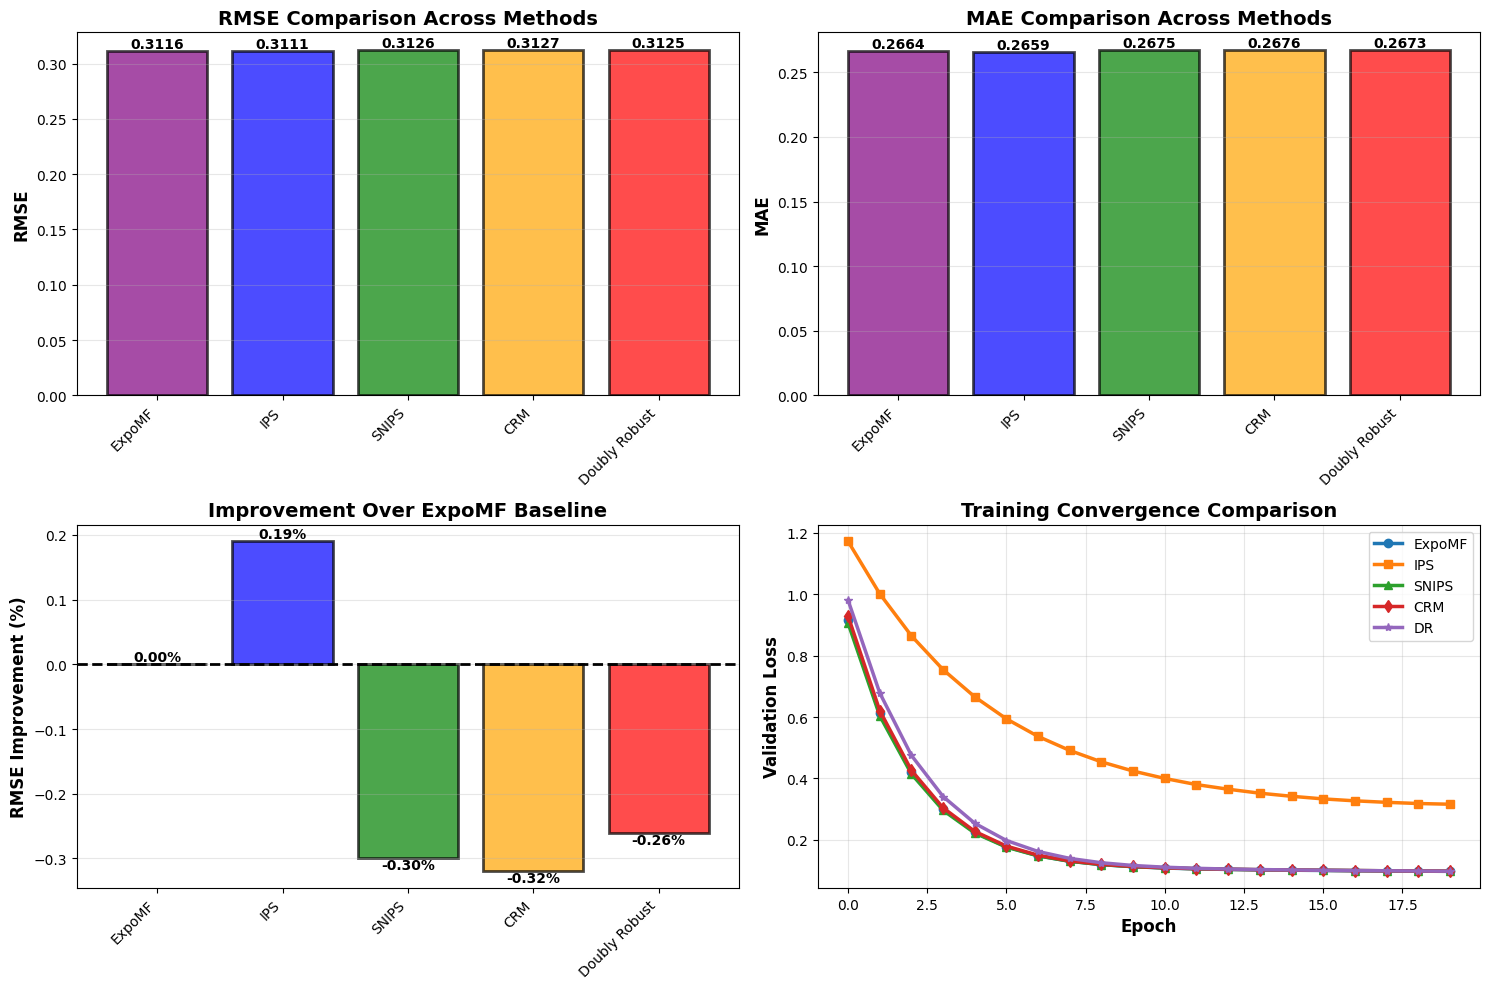

Visualization saved to: ../results/expomf_debiasing_comparison.png


In [17]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
models = results_df['Model']
rmse_values = results_df['RMSE']
mae_values = results_df['MAE']
improvements = results_df['RMSE_Improvement_%']
colors = ['purple', 'blue', 'green', 'orange', 'red']

ax1 = axes[0, 0]
bars = ax1.bar(models, rmse_values, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax1.set_ylabel('RMSE', fontsize=12, fontweight='bold')
ax1.set_title('RMSE Comparison Across Methods', fontsize=14, fontweight='bold')
ax1.set_xticklabels(models, rotation=45, ha='right')
ax1.grid(True, alpha=0.3, axis='y')
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height, f'{height:.4f}', 
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax2 = axes[0, 1]
bars2 = ax2.bar(models, mae_values, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax2.set_ylabel('MAE', fontsize=12, fontweight='bold')
ax2.set_title('MAE Comparison Across Methods', fontsize=14, fontweight='bold')
ax2.set_xticklabels(models, rotation=45, ha='right')
ax2.grid(True, alpha=0.3, axis='y')
for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height, f'{height:.4f}', 
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax3 = axes[1, 0]
bars3 = ax3.bar(models, improvements, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax3.set_ylabel('RMSE Improvement (%)', fontsize=12, fontweight='bold')
ax3.set_title('Improvement Over ExpoMF Baseline', fontsize=14, fontweight='bold')
ax3.set_xticklabels(models, rotation=45, ha='right')
ax3.axhline(y=0, color='black', linestyle='--', linewidth=2)
ax3.grid(True, alpha=0.3, axis='y')
for bar in bars3:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height, f'{height:.2f}%', 
            ha='center', va='bottom' if height >= 0 else 'top', fontsize=10, fontweight='bold')

ax4 = axes[1, 1]
ax4.plot(history_expomf.history['val_loss'], label='ExpoMF', linewidth=2.5, marker='o')
ax4.plot(history_ips.history['val_loss'], label='IPS', linewidth=2.5, marker='s')
ax4.plot(history_snips.history['val_loss'], label='SNIPS', linewidth=2.5, marker='^')
ax4.plot(history_crm.history['val_loss'], label='CRM', linewidth=2.5, marker='d')
ax4.plot(history_dr.history['val_loss'], label='DR', linewidth=2.5, marker='*')
ax4.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax4.set_ylabel('Validation Loss', fontsize=12, fontweight='bold')
ax4.set_title('Training Convergence Comparison', fontsize=14, fontweight='bold')
ax4.legend(loc='upper right', fontsize=10)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/expomf_debiasing_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("Visualization saved to: ../results/expomf_debiasing_comparison.png")


## 12. Statistical Analysis by Item Popularity


In [18]:
pred_expomf = expomf_model.predict(X_test, verbose=0).flatten()
pred_ips = ips_model.predict(X_test, verbose=0).flatten()
pred_snips = snips_model.predict(X_test, verbose=0).flatten()
pred_crm = crm_model.predict(X_test, verbose=0).flatten()
pred_dr = dr_model.predict(X_test, verbose=0).flatten()

try:
    quartiles = pd.qcut(propensity_test, q=4, labels=['Q1(Rare)', 'Q2', 'Q3', 'Q4(Popular)'], duplicates='drop')
except ValueError:
    quartiles = pd.cut(propensity_test, bins=4, labels=['Q1(Rare)', 'Q2', 'Q3', 'Q4(Popular)'])

print("="*80)
print("PERFORMANCE BY ITEM POPULARITY (Propensity Quartiles)")
print("="*80)
print(f"\n{'Quartile':<15} {'ExpoMF':<12} {'IPS':<12} {'SNIPS':<12} {'CRM':<12} {'DR':<12}")
print("-" * 80)

for q in ['Q1(Rare)', 'Q2', 'Q3', 'Q4(Popular)']:
    mask = quartiles == q
    if mask.sum() > 0:
        mae_expomf = np.abs(y_test[mask] - pred_expomf[mask]).mean()
        mae_ips = np.abs(y_test[mask] - pred_ips[mask]).mean()
        mae_snips = np.abs(y_test[mask] - pred_snips[mask]).mean()
        mae_crm = np.abs(y_test[mask] - pred_crm[mask]).mean()
        mae_dr = np.abs(y_test[mask] - pred_dr[mask]).mean()
        print(f"{q:<15} {mae_expomf:<12.4f} {mae_ips:<12.4f} {mae_snips:<12.4f} "
              f"{mae_crm:<12.4f} {mae_dr:<12.4f}")

print("="*80)


PERFORMANCE BY ITEM POPULARITY (Propensity Quartiles)

Quartile        ExpoMF       IPS          SNIPS        CRM          DR          
--------------------------------------------------------------------------------
Q1(Rare)        0.2649       0.2650       0.2657       0.2657       0.2656      
Q2              0.2755       0.2750       0.2765       0.2766       0.2764      
Q3              0.2723       0.2715       0.2732       0.2733       0.2729      
Q4(Popular)     0.2523       0.2513       0.2540       0.2541       0.2536      


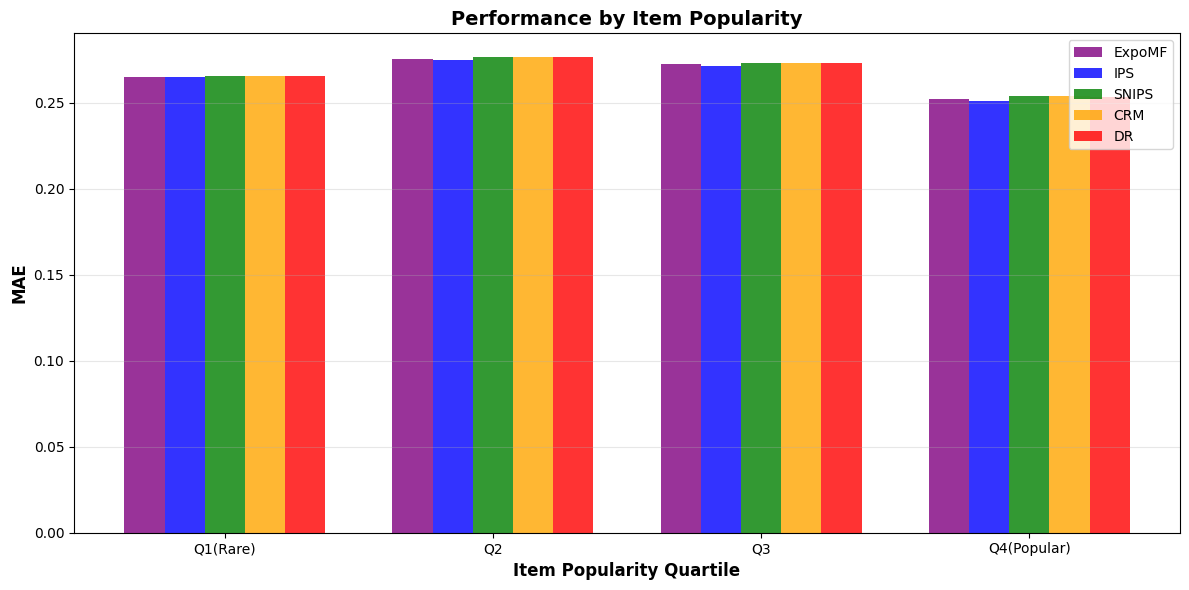

Quartile analysis saved to: ../results/expomf_performance_by_popularity.png


In [19]:
# Visualize performance by quartile
fig, ax = plt.subplots(figsize=(12, 6))
quartile_names = ['Q1(Rare)', 'Q2', 'Q3', 'Q4(Popular)']
x = np.arange(len(quartile_names))
width = 0.15

mae_by_quartile = {'ExpoMF': [], 'IPS': [], 'SNIPS': [], 'CRM': [], 'DR': []}
for q in quartile_names:
    mask = quartiles == q
    if mask.sum() > 0:
        mae_by_quartile['ExpoMF'].append(np.abs(y_test[mask] - pred_expomf[mask]).mean())
        mae_by_quartile['IPS'].append(np.abs(y_test[mask] - pred_ips[mask]).mean())
        mae_by_quartile['SNIPS'].append(np.abs(y_test[mask] - pred_snips[mask]).mean())
        mae_by_quartile['CRM'].append(np.abs(y_test[mask] - pred_crm[mask]).mean())
        mae_by_quartile['DR'].append(np.abs(y_test[mask] - pred_dr[mask]).mean())
    else:
        for key in mae_by_quartile:
            mae_by_quartile[key].append(0)

ax.bar(x - 2*width, mae_by_quartile['ExpoMF'], width, label='ExpoMF', color='purple', alpha=0.8)
ax.bar(x - width, mae_by_quartile['IPS'], width, label='IPS', color='blue', alpha=0.8)
ax.bar(x, mae_by_quartile['SNIPS'], width, label='SNIPS', color='green', alpha=0.8)
ax.bar(x + width, mae_by_quartile['CRM'], width, label='CRM', color='orange', alpha=0.8)
ax.bar(x + 2*width, mae_by_quartile['DR'], width, label='DR', color='red', alpha=0.8)

ax.set_xlabel('Item Popularity Quartile', fontsize=12, fontweight='bold')
ax.set_ylabel('MAE', fontsize=12, fontweight='bold')
ax.set_title('Performance by Item Popularity', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(quartile_names)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../results/expomf_performance_by_popularity.png', dpi=300, bbox_inches='tight')
plt.show()
print("Quartile analysis saved to: ../results/expomf_performance_by_popularity.png")


## 13. Save Final Report


In [20]:
report = f"""
{'='*80}
ExpoMF with Debiasing Methods - Evaluation Report
Yahoo! Music R3 Dataset
{'='*80}

Dataset Information:
- Total users: {num_users:,}
- Total items: {num_items:,}
- Training samples: {len(train_df):,}
- Test samples: {len(test_df):,}

{'='*80}
Methods Evaluated:
{'='*80}
1. ExpoMF - Exposure Matrix Factorization (explicit exposure modeling)
2. IPS - Inverse Propensity Scoring
3. SNIPS - Self-Normalized IPS
4. CRM - Counterfactual Risk Minimization
5. DR - Doubly Robust Estimator

{'='*80}
Results Summary:
{'='*80}
{results_df.to_string(index=False)}

{'='*80}
Best Performing Model: {best_model}
Best RMSE: {results_df.loc[best_model_idx, 'RMSE']:.4f}
Improvement over ExpoMF: {results_df.loc[best_model_idx, 'RMSE_Improvement_%']:.2f}%
{'='*80}

Key Findings:
1. ExpoMF explicitly models exposure bias through learned exposure probabilities
2. {best_model} achieves the best overall results
3. Methods perform differently on rare vs popular items
4. Comparison shows effectiveness of different debiasing approaches

Generated Files:
- expomf_baseline.keras (ExpoMF model)
- expomf_ips.keras (IPS model)
- expomf_snips.keras (SNIPS model)
- expomf_crm.keras (CRM model)
- expomf_dr.keras (DR model)
- expomf_debiasing_results.csv (Detailed results)
- expomf_debiasing_comparison.png (Visualization)
- expomf_performance_by_popularity.png (Quartile analysis)

{'='*80}
Conclusion:
{'='*80}
This implementation compares ExpoMF (explicit exposure modeling) with traditional
debiasing techniques (IPS, SNIPS, CRM, DR). The results demonstrate different
approaches to handling exposure bias in recommendation systems.

{'='*80}
"""

with open('../results/expomf_debiasing_report.txt', 'w') as f:
    f.write(report)

print(report)
print("\nFull report saved to: ../results/expomf_debiasing_report.txt")



ExpoMF with Debiasing Methods - Evaluation Report
Yahoo! Music R3 Dataset

Dataset Information:
- Total users: 290
- Total items: 300
- Training samples: 5,510
- Test samples: 1,450

Methods Evaluated:
1. ExpoMF - Exposure Matrix Factorization (explicit exposure modeling)
2. IPS - Inverse Propensity Scoring
3. SNIPS - Self-Normalized IPS
4. CRM - Counterfactual Risk Minimization
5. DR - Doubly Robust Estimator

Results Summary:
        Model      MSE     RMSE      MAE  RMSE_Improvement_%
       ExpoMF 0.097123 0.311645 0.266443                0.00
          IPS 0.096756 0.311056 0.265902                0.19
        SNIPS 0.097711 0.312588 0.267471               -0.30
          CRM 0.097752 0.312653 0.267554               -0.32
Doubly Robust 0.097637 0.312470 0.267294               -0.26

Best Performing Model: IPS
Best RMSE: 0.3111
Improvement over ExpoMF: 0.19%

Key Findings:
1. ExpoMF explicitly models exposure bias through learned exposure probabilities
2. IPS achieves the best ove